##Linear Regression 

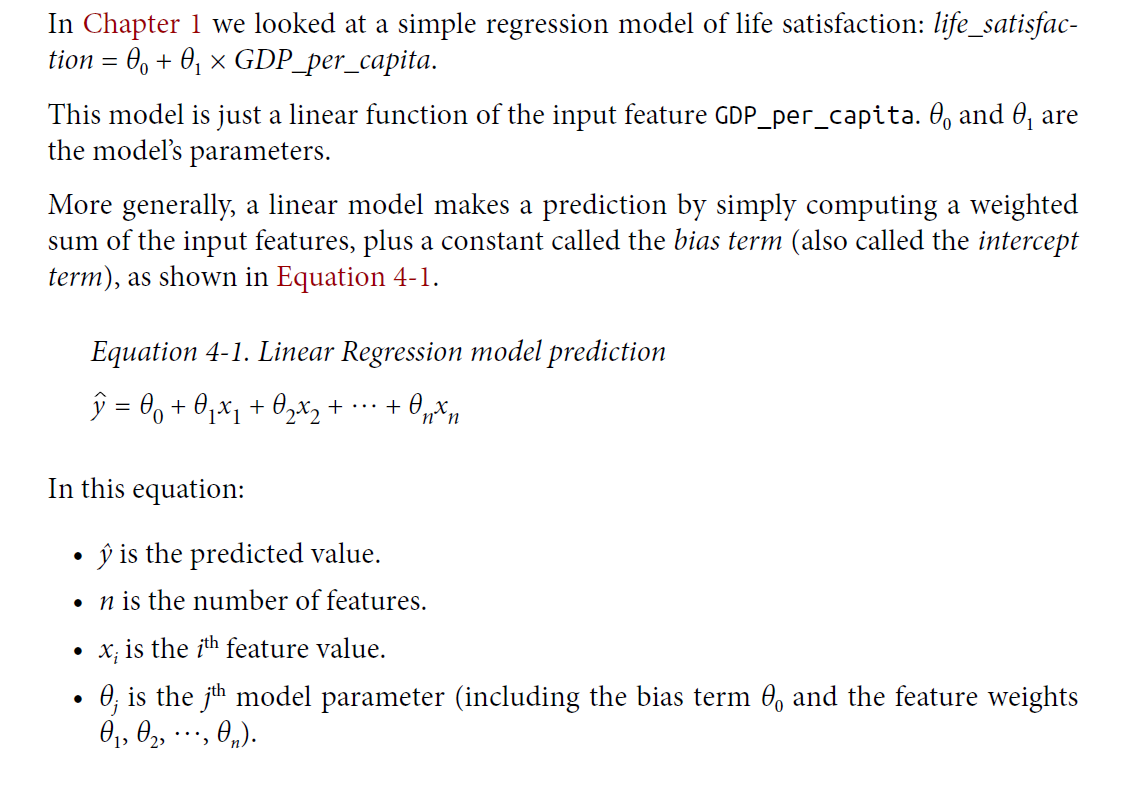

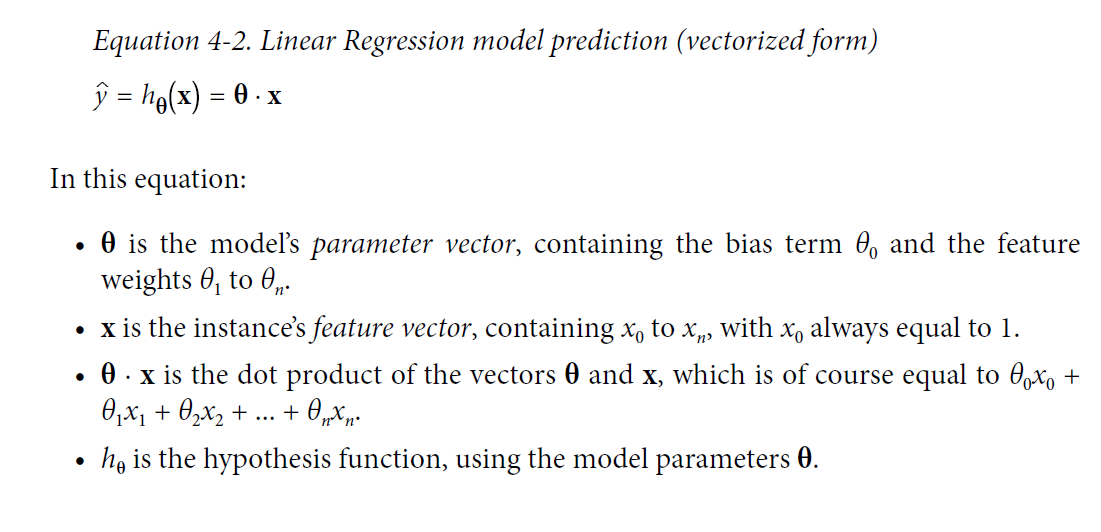

 we first need a measure of how well (or poorly) the model fits
the training data. In Chapter 2 we saw that the most common performance measure
of a regression model is the Root Mean Square Error (RMSE) (Equation 2-1). Therefore,
to train a Linear Regression model, we need to find the value of θ that minimizes
the RMSE. In practice, it is simpler to minimize the mean squared error (MSE)
than the RMSE, and it leads to the same result (because the value that minimizes a
function also minimizes its square root).1

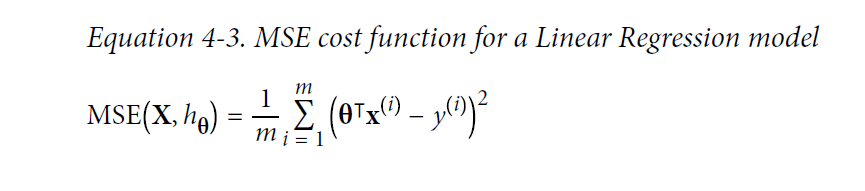

#Nornmal Equation

To find the value of θ that minimizes the cost function, there is a closed-form solution
—in other words, a mathematical equation that gives the result directly. This is called
the Normal Equation

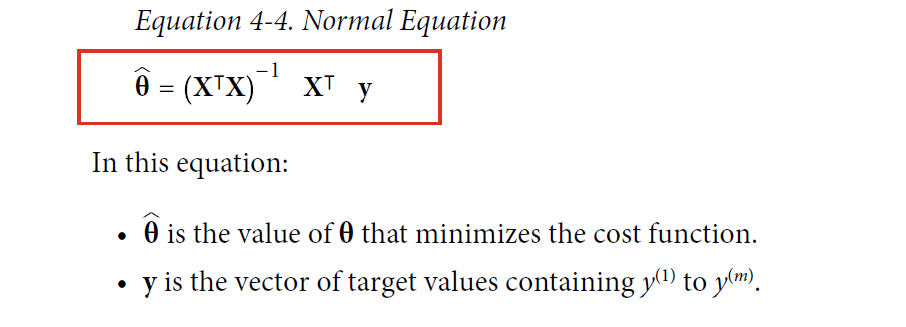

Let’s generate some linear-looking data to test this equation on (Figure 4-1):

In [3]:
import numpy as np

X = 2* np.random.rand(100,1)
y = 4+ 3*X +np.random.rand(100,1)

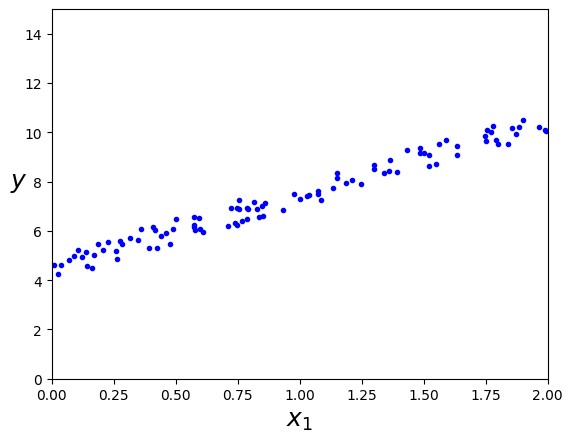

In [4]:
import matplotlib.pyplot as plt

# Assuming you already have X and y defined
plt.plot(X, y, "b.")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([0, 2, 0, 15])
plt.show()

well let's compute theta cap , we will use inv() from Numpy's limear algebra module(np.linalg) and dot() methods 

In [5]:
import numpy as np
X_b = np.c_[np.ones((100,1)), X] #add xo = 1 to each instance
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

The function that we used to generate the data is y = 4 + 3x1 + Gaussian noise. Let’s
see what the equation found

In [6]:
theta_best 

array([[4.5195526 ],
       [2.95433782]])

In [7]:
X_new = np.array([[0] , [2]])
X_new_b = np.c_[np.ones((2,1)),X_new] #add x0 = 1 to each instance
y_predict = X_new_b.dot(theta_best)
y_predict

array([[ 4.5195526 ],
       [10.42822823]])

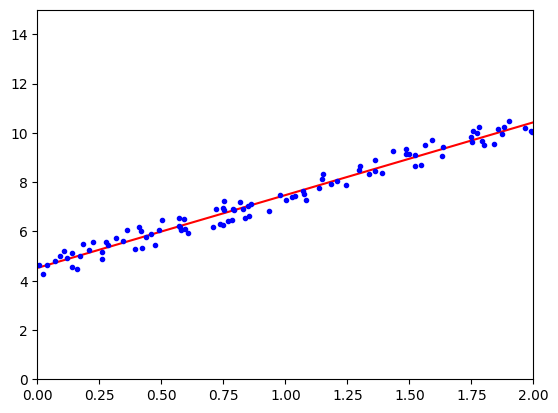

In [8]:
plt.plot(X_new, y_predict, "r-")
plt.plot(X, y, "b.")
plt.axis([0, 2, 0, 15])
plt.show()

well here we have trained our model and now we can use it to make predictions on new data. The red line represents the predictions made by our linear regression model, while the blue dots represent the original data points.`M`

In [9]:
#well here is the code which uses scikit-learn to do the same thing as above (the code above is the manual way of doing it)
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X,y)
lin_reg.intercept_, lin_reg.coef_

(array([4.5195526]), array([[2.95433782]]))

In [10]:
lin_reg.predict(X_new)

array([[ 4.5195526 ],
       [10.42822823]])

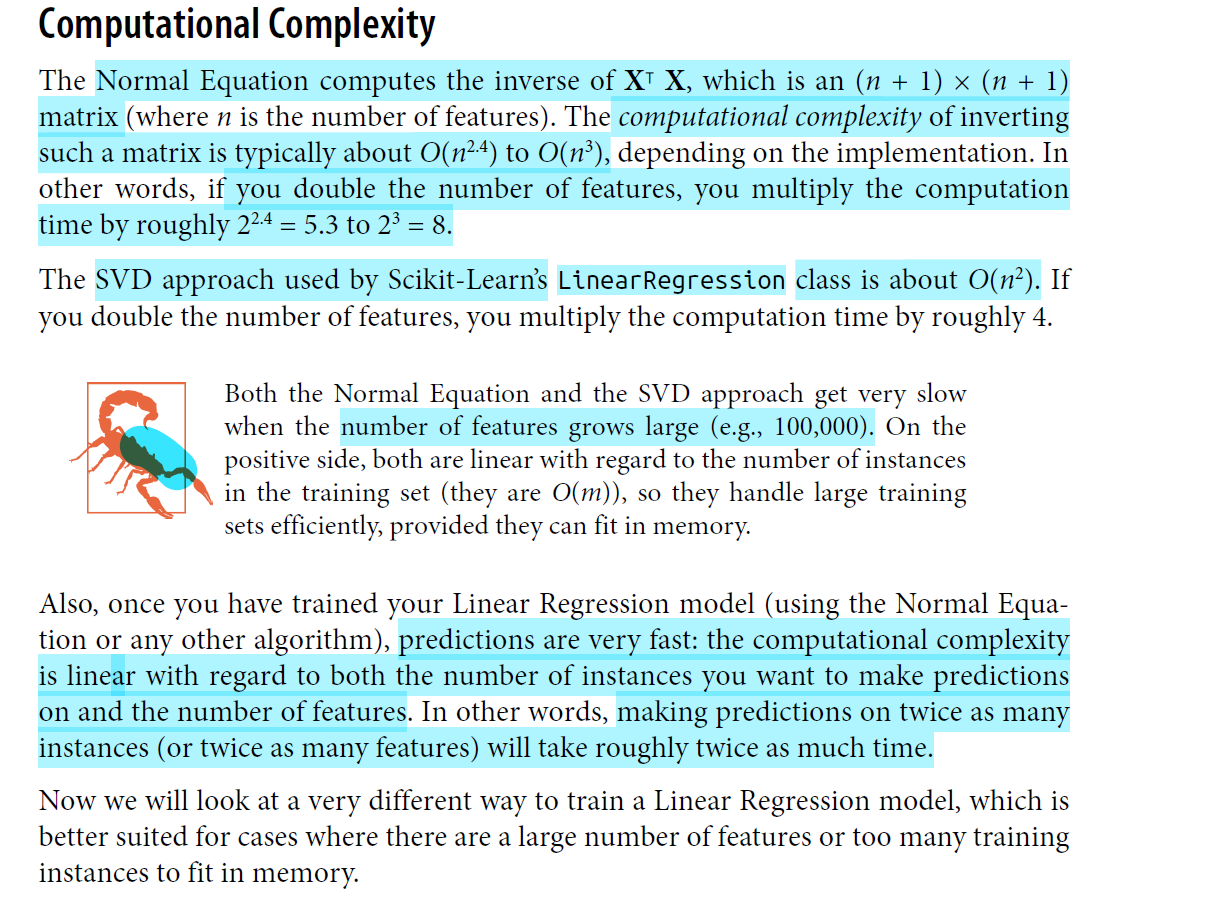

# Gradient Descent 

Here is a summary of the Gradient Descent algorithm as explained in Aurélien Géron's *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*.

### **The Core Concept**

Gradient Descent is a generic optimization algorithm capable of finding optimal solutions to a wide range of problems. The fundamental idea is to tweak a model's parameters iteratively in order to minimize a cost function.

The book uses a famous analogy to explain this: Imagine you are lost in the mountains in a dense fog. You can only feel the slope of the ground beneath your feet. A good strategy to get to the bottom of the valley quickly is to go downhill in the direction of the steepest slope.

Mathematically, the algorithm measures the local gradient of the error function with respect to the parameter vector $\boldsymbol{\theta}$, and it steps in the direction of the descending gradient. When the gradient is zero, you have reached a minimum.

---

### **Key Characteristics & Challenges**

* **Learning Rate:** This hyperparameter determines the size of the steps the algorithm takes. If it is too small, the algorithm will take a very long time to converge. If it is too large, it might jump across the valley and end up on the other side, potentially diverging and failing to find a good solution.
* **Global vs. Local Minima:** Not all cost functions look like perfectly smooth bowls. If the function has irregular terrain, the algorithm might settle into a "local minimum" (a shallow valley) instead of the "global minimum" (the absolute lowest point). Fortunately, the cost function for Linear Regression (Mean Squared Error) is a convex function, meaning it has no local minima, only one global minimum.
* **Feature Scaling:** Gradient Descent requires all features to have a similar scale (e.g., using Scikit-Learn's `StandardScaler`). If features have vastly different scales, the cost function will look like an elongated bowl. The algorithm will take a long time bouncing back and forth across the steep ridges before finally slowly making its way down to the minimum.

---

### **The Three Main Variants**

The book highlights three primary ways to implement Gradient Descent, differentiated by how much data they use to compute the gradient at each step.

| Variant | How It Works | Pros | Cons |
| --- | --- | --- | --- |
| **Batch Gradient Descent** | Uses the entire training dataset to compute the gradients at every single step. | Guaranteed to converge to the global minimum (for convex error surfaces). | Terribly slow on very large datasets because it has to process everything before taking one step. |
| **Stochastic Gradient Descent (SGD)** | Picks a single, random instance in the training set at every step and computes the gradient based only on that instance. | Extremely fast and can be trained out-of-core (on huge datasets). The randomness helps it jump out of local minima. | Highly erratic. It never truly settles at the minimum, but rather bounces around it continuously. |
| **Mini-batch Gradient Descent** | Computes the gradients on small, random sets of instances called "mini-batches." | A middle ground. You get a performance boost from hardware optimization of matrix operations (especially on GPUs). | Slightly harder to escape local minima than pure SGD. |

In [11]:
#implementing the batch gradient descent 

eta = 0.1 # learning rate
n_iterations = 1000 
m = 100 

theta = np.random.rand(2,1) #random imitialization 

for iterartion in range (n_iterations):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y )
    theta = theta - eta*gradients 

In [12]:
theta

array([[4.5195526 ],
       [2.95433782]])

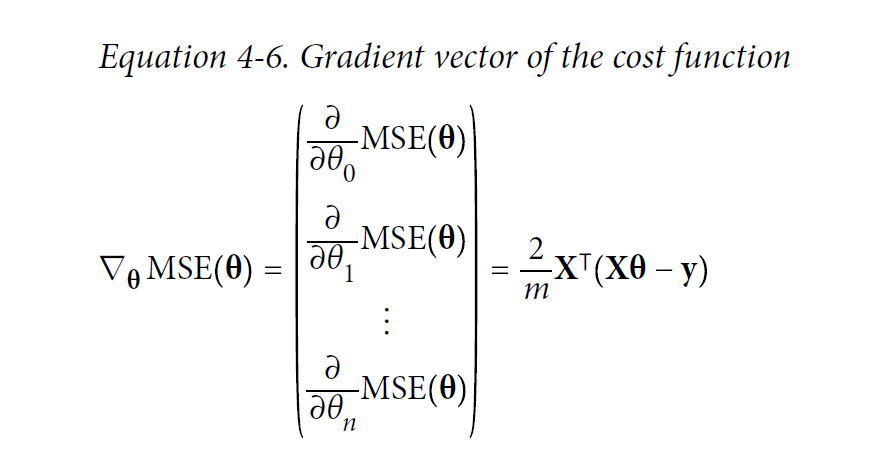